In [1]:
# Cell 1：加载数据
import json

import matplotlib.pyplot as plt
import pandas as pd

judge_data = []
with open("../data/eval/judge_results.jsonl", encoding="utf-8") as f:
    for line in f:
        r = json.loads(line)
        if "error" not in r:
            judge_data.append(r)

df = pd.DataFrame(judge_data)
print(f"Valid results: {len(df)}")
df.head()

Valid results: 200


,accuracy_a,fluency_a,style_a,accuracy_b,fluency_b,style_b,winner,reason,id
0,5,4,4,5,5,5,B,译文B在流畅性和风格上更适合短视频平台，表达更自然简洁。,0
1,5,4,3,5,5,4,B,译文B在流畅性和风格上更适合短视频平台，表达更自然。,1
2,5,5,5,4,5,5,A,译文A更准确地传达了原文的意思，尤其是在对糖尿病治愈的怀疑态度和研究结果的相关性方面。,2
3,5,4,4,5,5,5,B,译文B在流畅性和风格上更适合短视频平台，表达更简洁自然。,3
4,5,5,5,5,5,5,tie,两个译文在准确性、流畅性和风格上都表现得很好，几乎没有差别。,4


In [2]:
# Cell 2：核心指标
win_b = (df["winner"] == "B").mean()  # v2 胜率
win_a = (df["winner"] == "A").mean()  # v1 胜率
tie = (df["winner"] == "tie").mean()

print(f"V2 (revised) win rate:  {win_b:.1%}")
print(f"V1 (baseline) win rate: {win_a:.1%}")
print(f"Tie rate:               {tie:.1%}")

dims = ["accuracy", "fluency", "style"]
print("\nDimension improvements (V2 - V1):")
for d in dims:
    diff = df[f"{d}_b"].mean() - df[f"{d}_a"].mean()
    print(f"  {d:12s}: {diff:+.3f}")

V2 (revised) win rate:  46.0%
V1 (baseline) win rate: 38.0%
Tie rate:               16.0%

Dimension improvements (V2 - V1):
  accuracy    : -0.160
  fluency     : +0.200
  style       : +0.455


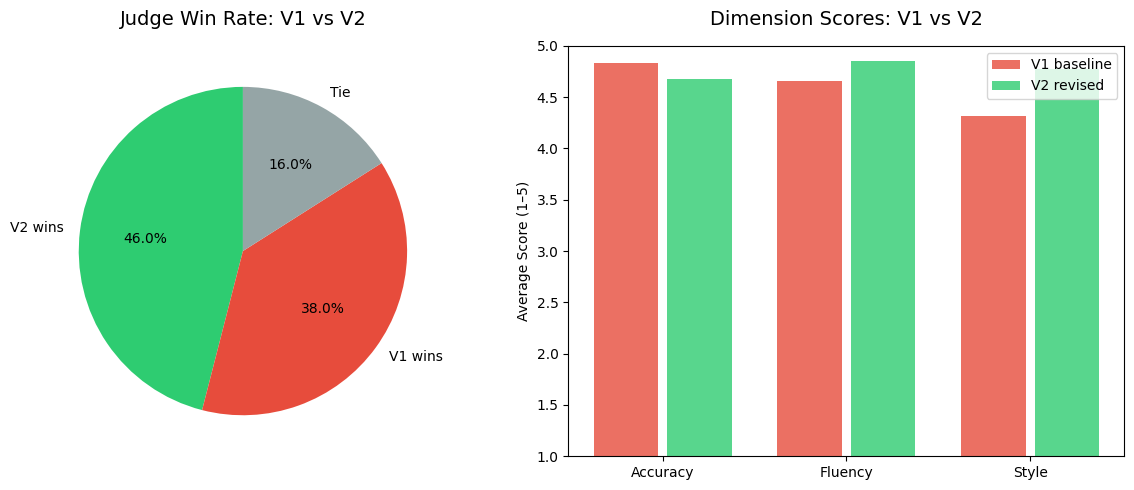

In [3]:
# Cell 3：图表
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 图1：Win Rate 饼图
ax1.pie(
    [win_b, win_a, tie],
    labels=["V2 wins", "V1 wins", "Tie"],
    colors=["#2ecc71", "#e74c3c", "#95a5a6"],
    autopct="%1.1f%%",
    startangle=90,
)
ax1.set_title("Judge Win Rate: V1 vs V2", fontsize=14, pad=15)

# 图2：各维度平均分对比
v1_scores = [df[f"{d}_a"].mean() for d in dims]
v2_scores = [df[f"{d}_b"].mean() for d in dims]
x = range(len(dims))
ax2.bar([i - 0.2 for i in x], v1_scores, 0.35, label="V1 baseline", color="#e74c3c", alpha=0.8)
ax2.bar([i + 0.2 for i in x], v2_scores, 0.35, label="V2 revised", color="#2ecc71", alpha=0.8)
ax2.set_xticks(list(x))
ax2.set_xticklabels(["Accuracy", "Fluency", "Style"])
ax2.set_ylim(1, 5)
ax2.set_ylabel("Average Score (1–5)")
ax2.set_title("Dimension Scores: V1 vs V2", fontsize=14, pad=15)
ax2.legend()

plt.tight_layout()
plt.savefig("../data/eval/judge_chart.png", dpi=150, bbox_inches="tight")
plt.show()

In [4]:
# Cell 4：稳定性实验
import json
import sys
import time
from pathlib import Path

sys.path.append(str(Path("../pipeline").resolve()))
from evaluate import judge_pairwise

pipeline_data = []
with open("../data/generated/pipeline_output.jsonl", encoding="utf-8") as f:
    for line in f:
        r = json.loads(line)
        if r.get("status") == "ok":
            pipeline_data.append(r)

test = pipeline_data[0]
print(f"Testing stability on sample {test['id']}...")
print(f"EN: {test['en'][:80]}")
print()

for i in range(3):
    r = judge_pairwise(test["en"], test["zh_v1"], test["zh_v2"])
    print(
        f"Run {i+1}: winner={r.get('winner')}  "
        f"accuracy_b={r.get('accuracy_b')}  "
        f"fluency_b={r.get('fluency_b')}  "
        f"style_b={r.get('style_b')}"
    )
    time.sleep(1)

print()
print("--- 解读提示（非结论）---")
print(
    "1) 本实验设定：judge_pairwise 使用 temperature=0，同 prompt 多次调用通常重复性较高。"
    "若三次结果一致，可能表示该条上优劣差距较明显或模型判断较确定；未必能推广到其他样本或温度设定。"
)
print(
    "2) 换设定时：提高温度、或两译文质量接近时，重复调用可能更易出现前后不一致；"
    "单条标量更适合当探索性参考；多条汇总（如胜率、各维均值）通常更有助于观察整体倾向，但仍需结合具体任务解读。"
)
print(
    "3) 阅读本次输出：请对照 Run 1–3 的 winner/分数，结合温度、样本是否难分等因素自行判断；此处仅为提示，不写死结论。"
)


Testing stability on sample 0...
EN: "We now have 4-month-old mice that are non-diabetic that used to be diabetic," h

Run 1: winner=B  accuracy_b=5  fluency_b=5  style_b=5
Run 2: winner=B  accuracy_b=5  fluency_b=5  style_b=5
Run 3: winner=B  accuracy_b=5  fluency_b=5  style_b=5

--- 解读提示（非结论）---
1) 本实验设定：judge_pairwise 使用 temperature=0，同 prompt 多次调用通常重复性较高。若三次结果一致，可能表示该条上优劣差距较明显或模型判断较确定；未必能推广到其他样本或温度设定。
2) 换设定时：提高温度、或两译文质量接近时，重复调用可能更易出现前后不一致；单条标量更适合当探索性参考；多条汇总（如胜率、各维均值）通常更有助于观察整体倾向，但仍需结合具体任务解读。
3) 阅读本次输出：请对照 Run 1–3 的 winner/分数，结合温度、样本是否难分等因素自行判断；此处仅为提示，不写死结论。
